# 1.0 Import Libraries
Goal: Import the required libraries for data analysis, visualization, machine learning, and model evaluation.

In [1]:
# Import libraries  - Second trial -> Working more with functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 2.0 Business Understanding
Goal: Predict future business applications by state using historical data.

# 2.1 Business Question 1
How have business application volumes changed over time across different states?

# 2.2 Business Question 2
What is the distribution of business application volumes in the dataset?

# 2.3 Business Question 3
Can historical data be used to predict future business application volumes for a given state?

# 3.0 Data Understanding
Goal: Explore the dataset, understand the available variables, identify patterns, and assess data quality through descriptive statistics and visualizations

In [2]:
# Define a function that gets a file_path of csv files and returns a dataframe (df)
def load_data(file_path):
    """
    Load a CSV file into a pandas DataFrame.
    As input: file_path (str): Path to the CSV file.
    Returns:pd.DataFrame: Loaded dataset.
    """
    df = pd.read_csv(file_path)
    return df
    
file_path=r"C:\Users\QE50MA\Downloads\bfs_ia_apps_annual.csv"
df=load_data(file_path)

In [3]:
# Define a function that recieves a dataframe and returns the first 5 rows as "head"
def dataframe_head(df):
    """
    Returns the first 5 rows of the dataframe
    As input: df (pd.DataFrame) - dataframe.
    Returns: d.DataFrame: First 5 rows of the dataframe.
    """
    return df.head()

dataframe_head(df)

,year,fstate,state,BA_NSA,HBA_NSA,WBA_NSA,CBA_NSA
0,2005,60,AS,164,73,61,25
1,2006,60,AS,136,79,57,35
2,2007,60,AS,179,105,74,46
3,2008,60,AS,202,84,52,27
4,2009,60,AS,285,107,61,34


In [4]:
# Basic EDA. Define a function that recieves a dataframe and returns df.info()
def show_info(df):
    """
    Returns df.info()
    As Input: df (pd.DataFrame) - dataframe.
    Returns: df.info()
    """
    return df.info()

show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   year     84 non-null     int64 
 1   fstate   84 non-null     int64 
 2   state    84 non-null     object
 3   BA_NSA   84 non-null     int64 
 4   HBA_NSA  84 non-null     int64 
 5   WBA_NSA  84 non-null     int64 
 6   CBA_NSA  84 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 4.7+ KB


In [5]:
# Basic EDA. Define a function that recieves a dataframe and returns df.describe()
def show_summary(df):
    """
    Returns df.describe()
    As input: df (pd.DataFrame) - dataframe.
    Returns: df.info()
    """
    return df.describe()

show_summary(df)

,year,fstate,BA_NSA,HBA_NSA,WBA_NSA,CBA_NSA
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,2015.000000,68.250000,597.738095,288.261905,158.011905,113.821429
std,6.091669,6.534201,478.576758,155.028806,82.797255,66.978177
min,2005.000000,60.000000,136.000000,73.000000,46.000000,22.000000
25%,2010.000000,64.500000,252.750000,139.250000,84.750000,50.250000
50%,2015.000000,67.500000,406.000000,295.000000,149.500000,102.000000
75%,2020.000000,71.250000,714.250000,418.250000,221.250000,159.250000
max,2025.000000,78.000000,2036.000000,576.000000,378.000000,304.000000


# 3.1 Missing Values
The dataset was checked for missing values using `df.isnull().sum()`.
No missing values were found in any of the columns. Therefore, no missing value treatment (such as dropping rows or imputation) was required.
Since the dataset was already complete, keeping the original data ensured that no information was unnecessarily removed or modified.

In [6]:
# Next, a function that checks for missing values
def missing_values(df):
    """
    Returns null or missing values
    As input: df (pd.DataFrame) - dataframe.
    Returns: df.isnull().sum()
    """
    return df.isnull().sum()

missing_values(df)

year       0
fstate     0
state      0
BA_NSA     0
HBA_NSA    0
WBA_NSA    0
CBA_NSA    0
dtype: int64

### Answer to Business Question 1
The line plot shows that business application volumes vary across states and over time. Some states (e.g. VI and GU) consistently record higher business application volumes than others, indicating differences in economic activity. 
The observed trends suggest that both the year and the state are important factors when analyzing and predicting business application volumes.

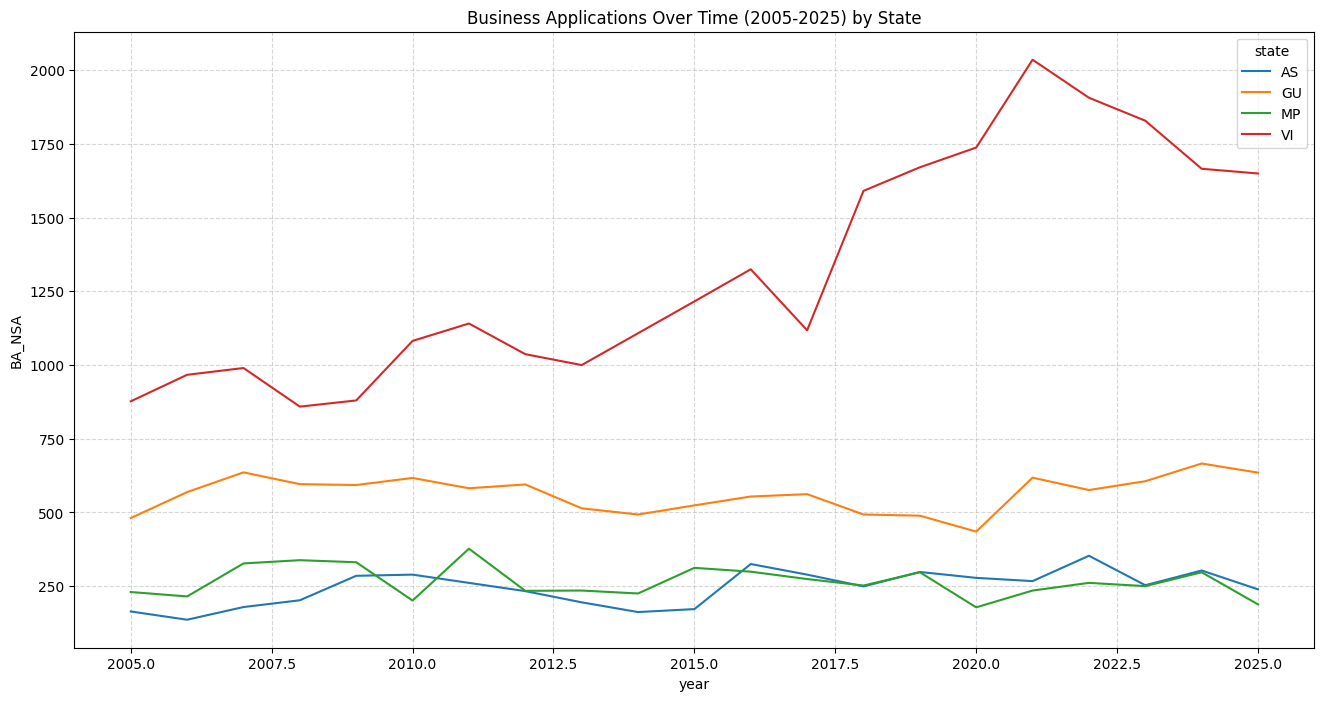

In [7]:
# Define a function that plots business applications volumes over time by state. This also answers the first business question
def plot_business_trend(df):
    """
    Plot business application trends over time for each state.
    As input: df (pd.DataFrame)-containing year, state, and BA_NSA columns.
    Display: it plots the abovementioned columns
    """
    plt.figure(figsize=(16, 8))
    sns.lineplot(data=df, x="year", y="BA_NSA", hue="state")
    plt.title("Business Applications Over Time (2005-2025) by State")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

plot_business_trend(df)

### Answer to Business Question 2

The histogram shows that most business application volumes are concentrated at the lower end of the scale, with a smaller number of observations having very high values. This creates a right-skewed distribution.

The KDE curve confirms that the majority of states and years report relatively low to moderate business application volumes, while only a few observations reach very high levels. This suggests that business application activity is not evenly distributed across the dataset and that some states experience significantly higher volumes than others.

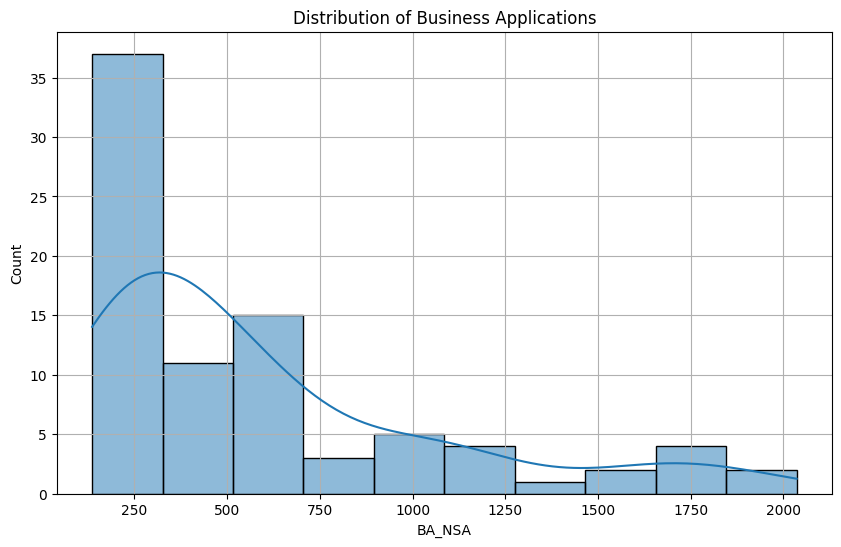

In [8]:
# Define a function that displays the histogram of BA_NSA values with a KDE curve. This also answers the second business question
def distribution_business_applications(df):
    """
    Plot the distribution of business applications
    As input: df (pd.DataFrame)-.
    Display: histogram of BA_NSA values with a KDE curve.
    """
    plt.figure(figsize=(10,6))
    sns.histplot(df["BA_NSA"], kde=True)
    plt.title("Distribution of Business Applications")
    plt.grid(True)
    plt.show()

distribution_business_applications(df)

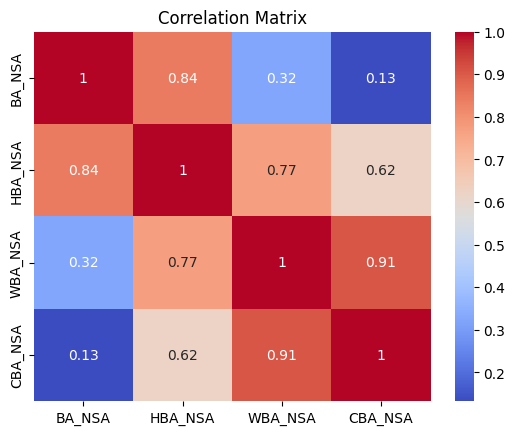

In [9]:
## Define a fun ction  that plots the correlation matrix for selected columns
def correlation_matrix(df):
    """
    Displays the correlation matrix for selected business application columns.
    Input: df (pd.DataFrame)
    Displays:Heatmap showing correlations between variables.
    """
    corr = df[["BA_NSA", "HBA_NSA", "WBA_NSA", "CBA_NSA"]].corr()

    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()
    
correlation_matrix(df)

# 4.0 Data Preparation
Goal: Clean and transform the data into a format suitable for machine learning, including encoding categorical variables and defining features and target variables.

# 4.1 Categorical Variables
The `state` column is a categorical variable and was encoded using label encoding (`astype("category").cat.codes`) because machine learning models require numerical input. 
The encoded values preserve the distinct categories while allowing the Random Forest model to process the data.

In [10]:
# Define a function that encodes categorical variables, specifically (state)
def cat_encoder(df, column):
    """
    Takes non categorical columns
    Input: df[column]
    Returns: encodedcolumn
    """
    df["encoded_" + column] =df[column].astype("category").cat.codes
    return df["encoded_" + column] 
    
cat_encoder(df, "state")

0     0
1     0
2     0
3     0
4     0
     ..
79    3
80    3
81    3
82    3
83    3
Name: encoded_state, Length: 84, dtype: int8

In [11]:
# Define a function that takes a dataframe and returns X and y as target and feature
def X_y_definition(df, featurecolumns, targetcolumn):
    """
    Takes dataframe, feature columns and target  column
    Returns: X and y (features and target column)
    """
    X = df[featurecolumns]
    y=df[targetcolumn]
    return X, y

X, y = X_y_definition(df, ["year", "encoded_state"], "BA_NSA")

In [12]:
# Define a function that splits the dataset into train and test
def split_data(X, y):
    """
    Takes feature columns and target  column
    Returns: splits feature columns and target column into train and test
    """
    return train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test=split_data(X, y)

# 5.0 Modeling
Goal: Train a machine learning model that can learn relationships between the input features and the number of business applications.

In [13]:
# Define a function that recieves X_train, y_train and trains and fits the model for RandomForestRegressor
def train_model(X_train, y_train):
    """
    Trains a Random Forest Regressor model.
    Input:
    X_train (pd.DataFrame): Training features.
    y_train (pd.Series): Training target.
    Returns:RandomForestRegressor: Trained model.
    """
    from sklearn.ensemble import RandomForestRegressor    # can also be imported upfront (cell1)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

model = train_model(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[1149.38  161.65  213.85  532.97  292.54 1089.92  209.26  328.21  218.59
  932.07  612.26  338.39  492.32 1843.62  282.57  298.25  533.97]


# 6.0 Evaluation
Goal: Assess how well the model performs using appropriate evaluation metrics and determine whether the predictions are reliable.

In [14]:
# define a function that takes y_test and y_pred and returns the evaluation metrics
def evaluate_model(y_test, y_pred):
    """
    Evaluates the model performance.
    Input:
    y_test (pd.Series): Actual values.
    y_pred (np.array): Predicted values.
    Returns:tuple: R2, MAE and RMSE scores.
    """
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, mae, rmse

r2, mae, rmse = evaluate_model(y_test, y_pred)
print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

The model achieved a high level of accuracy when predicting business application volumes.
R2: 0.9859787630617866
MAE: 41.843529411764685
RMSE: 53.19793660306317


# 7.0 Prediction / Deployment
Goal: Use the trained model to predict future business applications for a selected state and year based on user input.

In [15]:
# The model is ready. Let's define a function that recieves the abbreviation of a state, e.g. GU and returns the predictions. 
def predict_business_applications(model, df):
    """
    Predict business applications for a selected state and year.
    """
    state = input("Please Enter state abbreviation (e.g. 'AS', 'GU', 'MP', 'VI'): ")
    year = int(input("Enter prediction year: "))

    state_code = df[df["state"] == state]["encoded_state"].iloc[0]

    new_data = pd.DataFrame({"year": [year],"encoded_state": [state_code]})

    prediction = model.predict(new_data)
    
    print(f"Predicted Business Applications for {state} in {year}: {prediction[0]}")
    
    return prediction[0]

In [16]:
predict_business_applications(model, df)

Please Enter state abbreviation (e.g. 'AS', 'GU', 'MP', 'VI'):  GU
Enter prediction year:  2027


Predicted Business Applications for GU in 2027: 624.44


np.float64(624.44)

### Answer to Business Question 3

A Random Forest Regressor was trained using the year and encoded state information to predict business application volumes. The model was evaluated using R², MAE, and RMSE (results can be seen above), which provide insight into how accurately the model can make predictions.
Based on the evaluation results, historical business application data appears to be useful for estimating future business application volumes. The model was able to identify patterns in the data and generate predictions for different states and future years.
The relatively high R² score suggests that the model explains a substantial portion of the variation in business application volumes. While no prediction model is perfect, the results indicate that the Random Forest model provides a reasonable basis for forecasting future business application trends.